## EXPLORING THE CCM DATA

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [30]:
CCM = pd.read_parquet(r'C:\Users\zkx14\Downloads\CCM_dataset\CCM.parquet')

In [31]:
CCM.head()

,gvkey,fyear,datadate,permno,permco,at,sale,prcc_f,csho,ni,...,Industry,date,ret,vol,prc,shrout,sprtrn,vwretd,ewretd,retx
0,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-03-31,-12.3596,206200.0,9.750,2655.0,3.6796,0.0,5.6603,-12.3596
1,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-04-30,10.2564,143300.0,10.750,2655.0,3.6288,0.0,2.7087,10.2564
2,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-05-28,-19.7674,79600.0,8.625,2655.0,-4.1558,0.0,-4.9435,-19.7674
3,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-06-30,-4.3478,57200.0,8.250,2655.0,0.0703,0.0,-1.7240,-4.3478
4,1000,1970,1970-12-31,25881,23369,33.45,45.335,10.0,2.446,0.558,...,NaN,1971-07-30,-25.7576,37100.0,6.125,2655.0,-4.1324,0.0,-5.3634,-25.7576


Here it has a lot of columns but right now we only take the columns 'permno', 'date', 'ret', 'prc', 'shrout' as the final goals needs only these columns

* permno: A permanent security identifier assigned by CRSP to each individual security (issue). It does not change over time and is not reused.

* ret: The stock return for that security over the period ending on that date, usually including dividends and splits. 
        5% return = 0.05 ret
        120% return = 1.20 ret

* shrout: The number of shares outstanding for that security on that date

In [32]:
data = CCM[['permno','date','ret','prc','shrout','sale']]

In [33]:
data.head()

,permno,date,ret,prc,shrout,sale
0,25881,1971-03-31,-12.3596,9.750,2655.0,45.335
1,25881,1971-04-30,10.2564,10.750,2655.0,45.335
2,25881,1971-05-28,-19.7674,8.625,2655.0,45.335
3,25881,1971-06-30,-4.3478,8.250,2655.0,45.335
4,25881,1971-07-30,-25.7576,6.125,2655.0,45.335


In [34]:
# Ensure correct dtypes
data['date'] = pd.to_datetime(data['date'])
data['ret'] = pd.to_numeric(data['ret'], errors='coerce')
data['prc'] = pd.to_numeric(data['prc'], errors='coerce')
data['shrout'] = pd.to_numeric(data['shrout'], errors='coerce')

In [35]:
data.shape

(3060413, 6)

In [36]:
data.head()

,permno,date,ret,prc,shrout,sale
0,25881,1971-03-31,-12.3596,9.750,2655.0,45.335
1,25881,1971-04-30,10.2564,10.750,2655.0,45.335
2,25881,1971-05-28,-19.7674,8.625,2655.0,45.335
3,25881,1971-06-30,-4.3478,8.250,2655.0,45.335
4,25881,1971-07-30,-25.7576,6.125,2655.0,45.335


In [37]:
data.isna().sum()

permno        0
date          0
ret           0
prc           0
shrout        0
sale      11932
dtype: int64

# Exploratory data analysis

In [38]:
max_value = data['ret'].max()
min_value = data['ret'].min()

# Count how many times they appear
min_count = (data['ret'] == min_value).sum()
max_count = (data['ret'] == max_value).sum()

print(f"Lowest return: {min_value}, appears {min_count} times")
print(f"Highest return: {max_value}, appears {max_count} times")

Lowest return: -100.0, appears 7 times
Highest return: 2658.3827, appears 1 times


In [39]:
# Get the 10 lowest returns and their counts
lowest_10 = data['ret'].value_counts().sort_index().head(25)
print("Lowest 10 returns and their frequency:\n", lowest_10)

# Get the 10 highest returns and their counts
highest_10 = data['ret'].value_counts().sort_index(ascending=False).head(25)
print("\nHighest 10 returns and their frequency:\n", highest_10)

Lowest 10 returns and their frequency:
 ret
-100.0000    7
-99.5833     1
-99.3600     1
-98.4026     1
-98.1295     1
-98.0000     1
-97.8164     1
-97.6126     1
-97.4563     1
-97.3684     1
-97.2173     1
-97.1319     1
-96.8292     1
-96.5789     1
-96.4689     1
-96.4286     1
-96.4198     1
-96.2857     1
-96.2486     1
-96.1852     1
-96.1538     1
-96.1087     1
-96.0395     1
-95.9144     1
-95.9091     1
Name: count, dtype: int64

Highest 10 returns and their frequency:
 ret
2658.3827    1
2400.0000    1
2225.0870    1
1988.3590    1
1948.6034    1
1900.0000    1
1791.6667    1
1760.4651    1
1625.0531    1
1598.4456    1
1577.4194    1
1445.8015    1
1400.0000    1
1389.8000    1
1349.5050    1
1266.6667    1
1250.0000    1
1247.8261    1
1245.5858    1
1238.7097    1
1222.9025    1
1180.0000    1
1130.1676    1
1102.1277    1
1100.0000    1
Name: count, dtype: int64


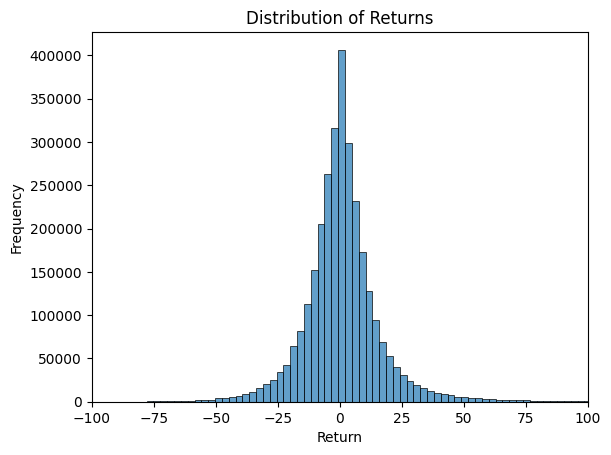

In [40]:
# Making a histigram to understand the overall markets return distribution
plt.hist(data['ret'], bins=1000, edgecolor='black', alpha=0.7, linewidth=0.7)
plt.xlim(-100, 100) 
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns')
plt.show()

* Returns are centered near zero → The average period return is close to zero, indicating most stock price changes are small gains or losses over the sample period.

* Approximately bell-shaped and normal distribution

* Possible slight negative skewness → Large negative returns appear somewhat more frequent or severe than large positive returns, consistent with downside risk asymmetry in equities.

* Presence of extreme returns → The dataset contains outliers with very large positive and negative returns, often due to corporate events like delistings, bankruptcies, or mergers.

## Equally-weighted portfolio

In Short, Equall weighted portfolio is like investing same amount of money in all the stocks available to you or in your tradable universe and all capital is allocated.

Here, weight(w) = 1/N , where N is the number of stock availabe to trade

Portfolio return = sum of the multiple of the weights and return of all the stocks at a speciic date. 

To build the equally weighted portfolio we need,
    "permo", "date", "ret"

In [44]:
ew = data[['permno','date','ret' ]]

In [ ]:
ew.head()

,permno,date,ret
0,25881,1971-03-31,-12.3596
1,25881,1971-04-30,10.2564
2,25881,1971-05-28,-19.7674
3,25881,1971-06-30,-4.3478
4,25881,1971-07-30,-25.7576


In [47]:
ew.isna().sum()

permno    0
date      0
ret       0
dtype: int64

In [48]:
ew.info()

<class 'pandas.DataFrame'>
RangeIndex: 3060413 entries, 0 to 3060412
Data columns (total 3 columns):
 #   Column  Dtype         
---  ------  -----         
 0   permno  int64         
 1   date    datetime64[us]
 2   ret     float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 70.0 MB


In [ ]:
"""
We now have to find out if we inversted 1 dollars on a equally weighted portfolio what would be the return

For that at first we need to know how the returns are of all the stocks and for that we groupby the date,
    .groupby("date", as_index = False) gives the permo and ret of a single date

since we have all the stocks and their returns for a specific date now we find the mean of the returns which
is done by the code line .agg(EW_ret = ('ret', 'mean'))

In short, ew_port groups the stock and return for a each specific date and then does the mean for all the returns
in that specific date hence giving a single float which can be used to calculate the portfolio's return

"""

ew_port = (
    ew
    .groupby('date', as_index=False)   # group all stocks by date
    .agg(EW_ret=('ret', 'mean'))      # average of ret = equally weighted return
)

In [ ]:
# Cumulative return to $1 investment

# sort by date 
ew_port = ew_port.sort_values('date').reset_index(drop=True)

# returns are in percent, so converting to gross return
ew_port['ret_plus1'] = 1 + ew_port['EW_ret'] / 100.0

# cumulative product → value of $1 over time
ew_port['cumRet'] = ew_port['ret_plus1'].cumprod()

print(ew_port.head())
print(ew_port[['EW_ret']].describe())

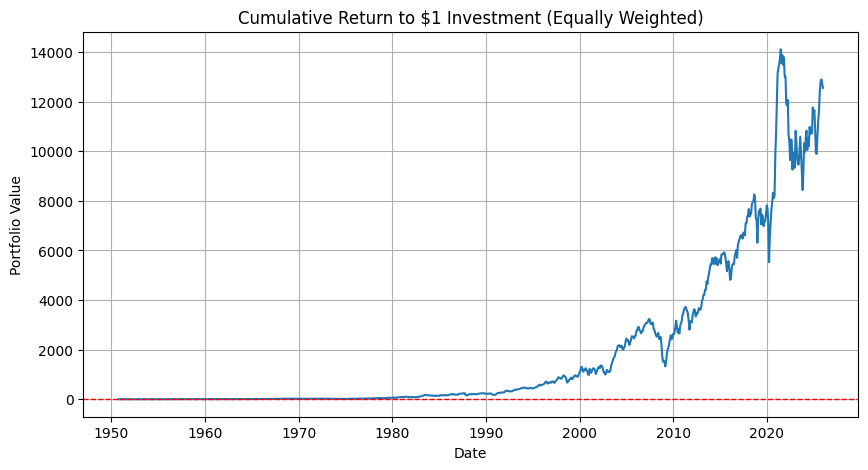

In [52]:
plt.figure(figsize=(10,5))
plt.plot(ew_port['date'], ew_port['cumRet'])
plt.axhline(1.0, color='red', linestyle='--', linewidth=1)
plt.title('Cumulative Return to $1 Investment (Equally Weighted)')
plt.xlabel('Date')
plt.ylabel('Portfolio Value')
plt.grid(True)
plt.show()